# mROSE sequence generation demo

This notebook runs compact mROSE generation examples for the three major mRNA regions and shows only the key results. The checked-in outputs were generated on the project server with the released checkpoints.


<p align="center">
  <img src="../docs/assets/mrose-icon.png" alt="mROSE icon" width="150">
</p>

<p align="center">
  <img src="../docs/assets/mrose-figure1.png" alt="mROSE workflow" width="900">
</p>


## 1. Setup

The notebook assumes it is run from either the repository root or the `notebooks/` directory. Generation logs are captured internally so the visible output stays focused on results.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
if (cwd / "mrose").is_dir():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "mrose").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



## 2. Readiness check

Only essential readiness information is shown. Checkpoint file sizes are intentionally omitted from the notebook output.


In [2]:
import importlib.util

required_modules = ["numpy", "pandas", "torch", "Bio", "sklearn", "scipy", "tqdm"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
vienna_ready = importlib.util.find_spec("ViennaRNA") is not None or importlib.util.find_spec("RNA") is not None

checkpoint_paths = {
    "5' UTR": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
    "CDS": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
    "3' UTR": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
}
missing_checkpoints = [name for name, path in checkpoint_paths.items() if not path.exists()]

print("Environment:", "ready" if not missing_modules else "missing " + ", ".join(missing_modules))
print("RNA folding:", "ready" if vienna_ready else "not available")
print("Checkpoints:", "ready" if not missing_checkpoints else "missing " + ", ".join(missing_checkpoints))


Environment: ready
RNA folding: ready
Checkpoints: ready


## 3. Run compact generation demos

The commands below generate 20 candidates per region and keep the top 5. Verbose command-line logs are saved internally and summarized after each task.


In [3]:
TASKS = {
    "5' UTR": {
        "script": PROJECT_ROOT / "generation" / "5utr" / "generate_5utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "5utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--output_prefix", "demo_5utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo" / "demo_5utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo" / "demo_5utr_all_scored.csv",
    },
    "CDS": {
        "script": PROJECT_ROOT / "generation" / "cds" / "generate_cds.py",
        "checkpoint": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "cds_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "cds_demo",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--mfe_weight", "0"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_demo" / "top10_generated_scored.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_demo" / "all_generated_scored.csv",
    },
    "3' UTR": {
        "script": PROJECT_ROOT / "generation" / "3utr" / "generate_3utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "3utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--match_input_length", "--output_prefix", "demo_3utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo" / "demo_3utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo" / "demo_3utr_all_scored.csv",
    },
}

run_logs = {}
for region, cfg in TASKS.items():
    cfg["output_dir"].mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable,
        str(cfg["script"]),
        "--checkpoint", str(cfg["checkpoint"]),
        "--input_fasta", str(cfg["input_fasta"]),
        "--output_dir", str(cfg["output_dir"]),
        *cfg["args"],
    ]
    run_env = os.environ.copy()
    run_env.setdefault("MKL_THREADING_LAYER", "GNU")
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        env=run_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )
    run_logs[region] = result.stdout
    if result.returncode != 0:
        print(run_logs[region])
        raise RuntimeError(f"{region} generation failed with exit code {result.returncode}")
    print(f"{region}: generated top candidates -> {cfg['top_csv'].relative_to(PROJECT_ROOT)}")


5' UTR: generated top candidates -> outputs/generation/5utr_demo/demo_5utr_top5.csv
CDS: generated top candidates -> outputs/generation/cds_demo/top10_generated_scored.csv
3' UTR: generated top candidates -> outputs/generation/3utr_demo/demo_3utr_top5.csv


## 4. Result tables

The tables show the top candidates with only the most useful design metrics. Long sequences are shortened for readability.


In [4]:
def shorten_sequence(sequence, width=42):
    sequence = str(sequence)
    if len(sequence) <= width:
        return sequence
    flank = max(8, (width - 3) // 2)
    return f"{sequence[:flank]}...{sequence[-flank:]}"


def standardize_region_table(region, path):
    df = pd.read_csv(path).head(5).copy()
    df.insert(0, "region", region)
    if "rank" not in df.columns:
        df.insert(1, "rank", np.arange(1, len(df) + 1))
    if region == "5' UTR":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["mrl_pred"],
            "primary_label": "MRL",
            "gc": df["GC"],
            "mfe": df["mfe"],
            "cai": np.nan,
            "length": df["sequence"].astype(str).str.len(),
            "sequence": df["sequence"],
        })
    elif region == "CDS":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "pred_value",
            "gc": df["gc"],
            "mfe": df["MFE"],
            "cai": df["CAI"],
            "length": df["length_nt"],
            "sequence": df["sequence"],
        })
    else:
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "degradation_pred",
            "gc": df["GC"],
            "mfe": df["MFE"],
            "cai": np.nan,
            "length": df["length"],
            "sequence": df["sequence"],
        })
    out["sequence_preview"] = out["sequence"].map(shorten_sequence)
    return out

region_tables = [standardize_region_table(region, cfg["top_csv"]) for region, cfg in TASKS.items()]
summary = pd.concat(region_tables, ignore_index=True)
summary_view = summary[["region", "rank", "final_score", "primary_label", "primary_metric", "gc", "mfe", "cai", "length", "sequence_preview"]].copy()
for col in ["final_score", "primary_metric", "gc", "mfe", "cai"]:
    summary_view[col] = summary_view[col].astype(float).round(4)
print(summary_view.to_string(index=False))


region  rank  final_score    primary_label  primary_metric     gc    mfe    cai  length                          sequence_preview
5' UTR     1       0.8330              MRL          6.7100 0.4667  -0.40    NaN      45 AGGAGCCATACTGTTGAAG...GAAAATCACAGAAGCCACC
5' UTR     2       0.8244              MRL          6.7949 0.5200  -5.07    NaN      50 AGGTCTGTCGAAAGAGAAC...GACTAGAACAGGGGCCACC
5' UTR     3       0.8166              MRL          6.7943 0.5745  -6.60    NaN      47 AGGTCAGCGACACTAGCAC...AACGGATTACGGGGCCACC
5' UTR     4       0.8157              MRL          6.6810 0.5000  -2.80    NaN      56 AGGAGGGAGATCGACTGAG...ACAAATTTTCAGGGCCACC
5' UTR     5       0.8149              MRL          6.7365 0.5714  -4.90    NaN      49 AGGAAACAGGGAACAGAGG...AGGCAAATCTAGTGCCACC
   CDS     1       0.8242       pred_value          1.2658 0.5470 -38.30 0.6212     117 ATGGCGGAAGAGCTGTTCA...AACCGAGGCTGCCGAATAA
   CDS     2       0.7853       pred_value          1.1204 0.5385 -34.00 0.6860     117 AT

## 5. Region-specific result plots

These plots focus on the most relevant metrics for each generated region: MRL and MFE for 5′ UTR, degradation prediction and MFE for 3′ UTR, and a three-dimensional view of CDS prediction, MFE and CAI.


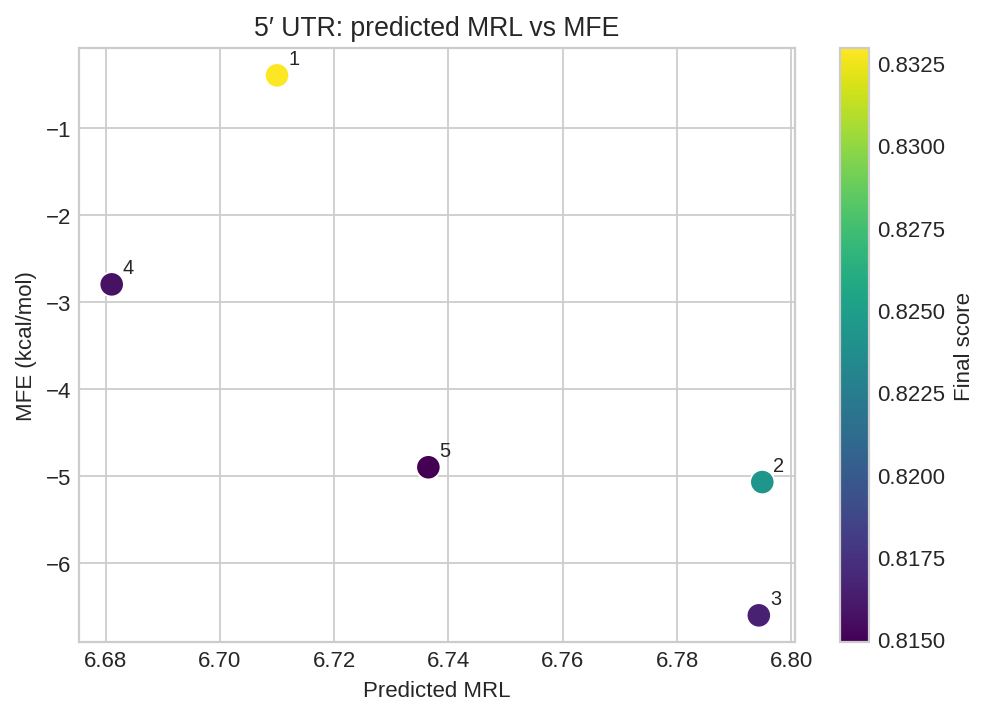

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = {"5' UTR": "#1b9e77", "CDS": "#386cb0", "3' UTR": "#f28e2b"}

five_utr = summary[summary["region"] == "5' UTR"].copy()
fig, ax = plt.subplots(figsize=(6.4, 4.6))
points = ax.scatter(
    five_utr["primary_metric"],
    five_utr["mfe"],
    c=five_utr["final_score"],
    cmap="viridis",
    s=120,
    edgecolor="white",
    linewidth=0.8,
)
for _, row in five_utr.iterrows():
    ax.annotate(int(row["rank"]), (row["primary_metric"], row["mfe"]), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Predicted MRL")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_title("5′ UTR: predicted MRL vs MFE")
fig.colorbar(points, ax=ax, label="Final score")
fig.tight_layout()
plt.show()


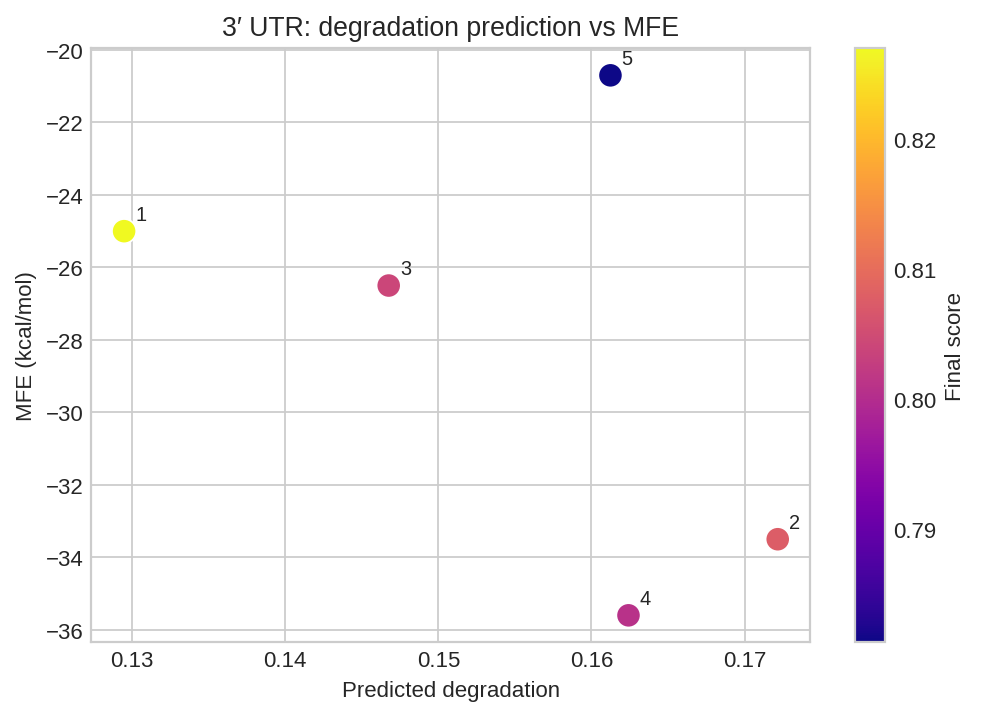

In [6]:
three_utr = summary[summary["region"] == "3' UTR"].copy()
fig, ax = plt.subplots(figsize=(6.4, 4.6))
points = ax.scatter(
    three_utr["primary_metric"],
    three_utr["mfe"],
    c=three_utr["final_score"],
    cmap="plasma",
    s=120,
    edgecolor="white",
    linewidth=0.8,
)
for _, row in three_utr.iterrows():
    ax.annotate(int(row["rank"]), (row["primary_metric"], row["mfe"]), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Predicted degradation")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_title("3′ UTR: degradation prediction vs MFE")
fig.colorbar(points, ax=ax, label="Final score")
fig.tight_layout()
plt.show()


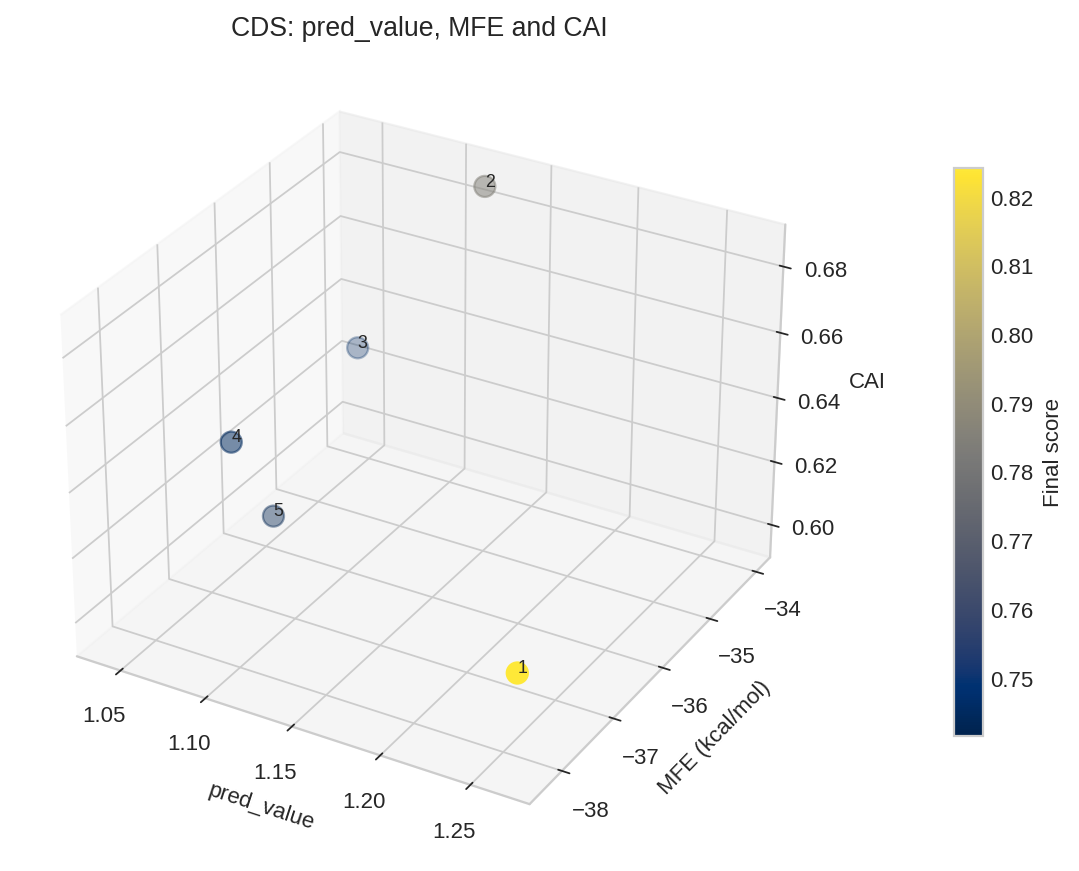

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

cds = summary[summary["region"] == "CDS"].copy()
fig = plt.figure(figsize=(7.2, 5.6))
ax = fig.add_subplot(111, projection="3d")
points = ax.scatter(
    cds["primary_metric"],
    cds["mfe"],
    cds["cai"],
    c=cds["final_score"],
    cmap="cividis",
    s=90,
    depthshade=True,
)
for _, row in cds.iterrows():
    ax.text(row["primary_metric"], row["mfe"], row["cai"], str(int(row["rank"])), fontsize=8)
ax.set_xlabel("pred_value")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_zlabel("CAI")
ax.set_title("CDS: pred_value, MFE and CAI")
fig.colorbar(points, ax=ax, shrink=0.68, pad=0.12, label="Final score")
fig.tight_layout()
plt.show()


## 6. Output files

In [8]:
for region, cfg in TASKS.items():
    print(f"{region}: {cfg['top_csv'].relative_to(PROJECT_ROOT)}")


5' UTR: outputs/generation/5utr_demo/demo_5utr_top5.csv
CDS: outputs/generation/cds_demo/top10_generated_scored.csv
3' UTR: outputs/generation/3utr_demo/demo_3utr_top5.csv
